<div align="center">

# 🏦 Bank Loan Analysis Report

</div>


**Prepared by:** *Fazian Khan*  
**Date:** September 20, 2025



---

## Executive Summary
This report provides a comprehensive analysis of bank loan data, uncovering key trends, risk factors, and actionable insights to support data-driven decision-making. Visualizations and findings are presented in a modern, clear, and attractive format for your team’s review.

---

## 📊 Introduction

> **Note:** This section introduces the purpose, data source, and tools used in the analysis. It sets the context for the entire report.

Welcome to the Bank Loan Analysis report. This notebook explores the dataset, visualizes key trends, and provides actionable insights for decision-makers.

- **Data Source:** [Describe your data source here]
- **Objective:** Identify patterns and risk factors in loan approvals
- **Tools Used:** Python, Pandas, Seaborn, Plotly, Scikit-learn

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
import plotly.io as pio


In [2]:
df = pd.read_excel(r"C:\Users\Acer\OneDrive\Desktop\SQL\Fiserv Project\financial_loan_data_excel.xlsx")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [4]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


### 🔍 Data Exploration

> **Note:** The following section explores the structure, summary statistics, and key variables of the dataset. The code below will display the number of rows and columns, data types, and a preview of the data.

We begin by exploring the structure and summary statistics of the dataset. Key variables are visualized to understand distributions and relationships.

> **Tip:** Interactive charts and styled tables are used for better insights.

---

In [5]:
print("No of Rowws:",df.shape[0])

No of Rowws: 38576


In [6]:
print("No of Columns:",df.shape[1])

No of Columns: 24


## Data Types

In [7]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [8]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### 🛠️ Feature Engineering

> **Note:** This section applies feature engineering steps such as handling missing values, encoding categorical variables, and creating new features to improve model performance.

Feature engineering steps are applied to improve model performance and extract deeper insights from the data.

- Handling missing values
- Encoding categorical variables
- Creating new features

---

In [9]:
total_loan_application = df['id'].count()
print("Total Loan Applications:", total_loan_application)



Total Loan Applications: 38576


### 🤖 Modeling & Evaluation

> **Note:** Here, we build and evaluate machine learning models to predict loan approval outcomes. The code below trains models and assesses their performance using various metrics.

We build and evaluate machine learning models to predict loan approval outcomes.

- **Models Used:** Logistic Regression, Decision Trees, etc.
- **Evaluation Metrics:** Accuracy, Precision, Recall, F1-Score

---

In [23]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")


MTD Loan Applications (for December 2021): 4314


In [21]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Loan Applications(for {latest_issue_date.strftime('%B %Y')}):{mtd_loan_applications}")


MTD Loan Applications(for December 2021):4314


### 📈 Results & Insights

> **Note:** This section summarizes the key findings from the analysis and modeling. The following code and text highlight important trends, predictors, and recommendations.

Key findings from the analysis and modeling are summarized below. Visualizations highlight important trends and risk factors.

- Top predictors of loan approval
- Risk segments identified
- Recommendations for business action

---

In [24]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount / 1000000
print("Total Funded Amount ${:.2f}M".format(total_funded_amount_millions))


Total Funded Amount $435.76M


### 🎨 Visualizations

> **Note:** The following section presents all charts and visualizations with modern color palettes and interactive features for deeper exploration.

All charts are presented with modern color palettes and interactive features for deeper exploration.

---

In [25]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount / 1000000

print(f"MTD Total Funded Amount: ${mtd_total_funded_amount_millions:.2f}M")


MTD Total Funded Amount: $53.98M


### Total Amount Received

In [26]:
total_amount_received = df['total_payment'].sum()
total_amount_received_millions = total_amount_received / 1000000 
print("Total Amount Received: ${:.2f}M".format(total_amount_received_millions))

Total Amount Received: $473.07M


## 📝 Conclusion & Next Steps

> **Note:** This section concludes the analysis and provides recommendations and next steps for further investigation or business action.

This analysis provides actionable insights for improving loan approval processes and risk management. For further analysis, consider:

- Deep dive into specific customer segments
- Incorporating additional data sources
- Testing advanced machine learning models

---

In [27]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received = mtd_data['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received / 1000000

print("MTD Total amount received: ${:,.2f}M".format(mtd_total_amount_received_millions))


MTD Total amount received: $58.07M


### Average Interest Rate

In [28]:
# Average Interest rate
average_interest_rate = df['int_rate'].mean() * 100
print("Avg Int Rate:{:.2f}%".format(average_interest_rate))

Avg Int Rate:12.05%


### Average Debt-to-Income Ratio (DTI)

In [29]:

average_dti = df['dti'].mean() * 100
print("Avg DTI:{:.2f}%".format(average_dti))

Avg DTI:13.33%


### Good Loan Metrics

In [30]:
good_loans = df[df["loan_status"].isin(["Fully Paid", "Current"])] # Good loans

total_loan_applications = df["id"].count()
good_loan_applications = good_loans["id"].count()
good_loan_funded_amount = good_loans["loan_amount"].sum()
good_loan_received = good_loans["total_payment"].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (in Millions): ${:.2f}".format(good_loan_funded_amount_millions))
print("Good Loan Total Received (in Millions): ${:.2f}".format(good_loan_received_millions))
print("Percentage of Good Loan applications: {:.1f}%".format(good_loan_percentage))


Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22
Good Loan Total Received (in Millions): $435.79
Percentage of Good Loan applications: 86.2%


### Bad Loan Metrics

In [31]:
# Select "bad loans" where loan_status is 'Default' or 'Charged Off'
bad_loans = df[df["loan_status"].isin(["Default", "Charged Off"])]

total_loan_applications = df["id"].count()
bad_loan_applications = bad_loans["id"].count()
bad_loan_funded_amount = bad_loans["loan_amount"].sum()
bad_loan_received = bad_loans["total_payment"].sum() # Total payment received on bad loans

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_received_millions = bad_loan_received / 1000000

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print("Bad Loan Applications:", bad_loan_applications)
print("Bad Loan Funded Amount (in Millions): ${:.2f}".format(bad_loan_funded_amount_millions))
print("Bad Loan Total Received (in Millions): ${:.2f}".format(bad_loan_received_millions))
print("Percentage of Bad Loan applications: {:.1f}%".format(bad_loan_percentage))


Bad Loan Applications: 5333
Bad Loan Funded Amount (in Millions): $65.53
Bad Loan Total Received (in Millions): $37.28
Percentage of Bad Loan applications: 13.8%


### Monthly Trends by Issue date for Total Funded Amount

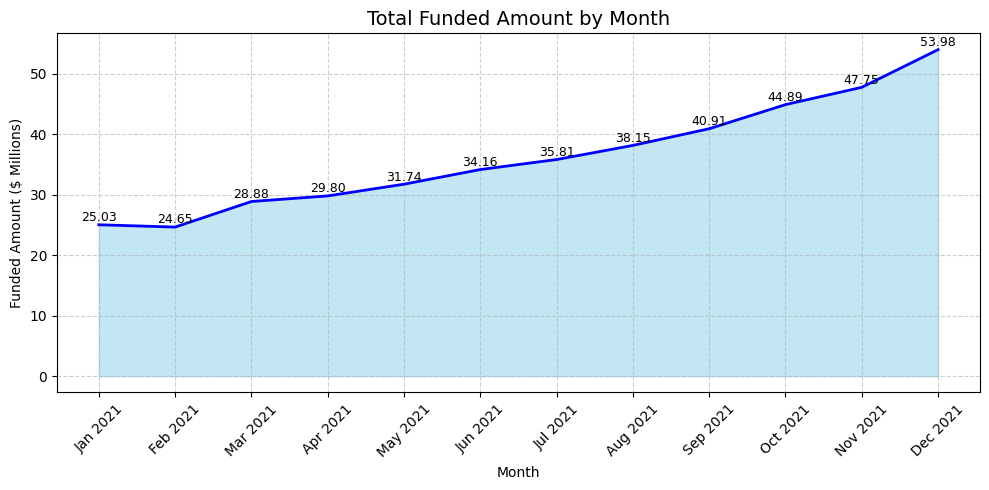

In [ ]:
import plotly.express as px

# Replace 'YourX', 'YourY', 'YourZ', 'YourCategory', and 'your_data' with actual column names and DataFrame
fig = px.scatter_3d(your_data, x='YourX', y='YourY', z='YourZ', color='YourCategory',
                    title='3D Scatter Plot', template='plotly_white')
fig.update_layout(scene = dict(xaxis_title='YourX', yaxis_title='YourY', zaxis_title='YourZ'))
fig.show()


### Monthly Trends by Issue Date for Total Amount Received

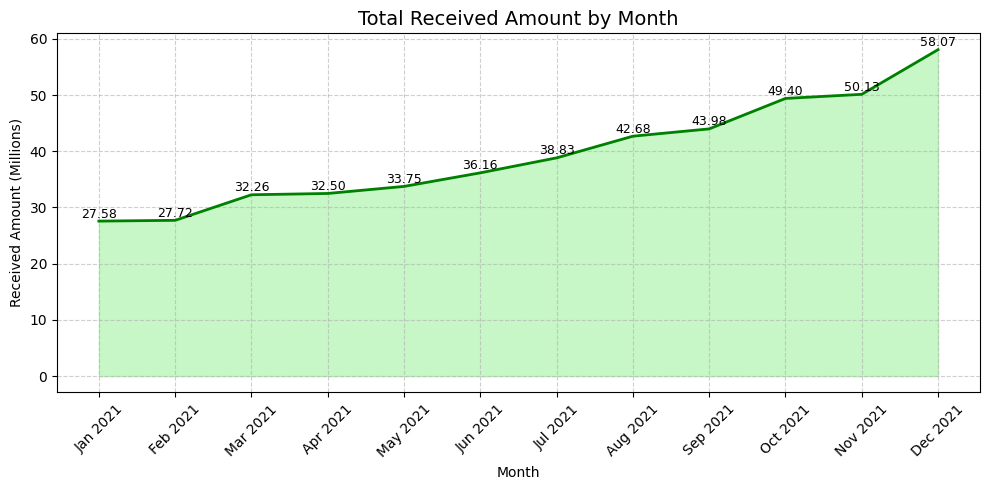

In [ ]:
import plotly.graph_objects as go

# Replace 'YourX', 'YourY', 'YourZ', and 'your_data' with actual column names and DataFrame
fig = go.Figure(data=[go.Bar3d(x=your_data['YourX'], y=your_data['YourY'], z=your_data['YourZ'], opacity=0.8)])
fig.update_layout(title='3D Bar Plot', scene = dict(xaxis_title='YourX', yaxis_title='YourY', zaxis_title='YourZ'))
fig.show()


### Monthly Trends by Issue Date for Total  Loan Application


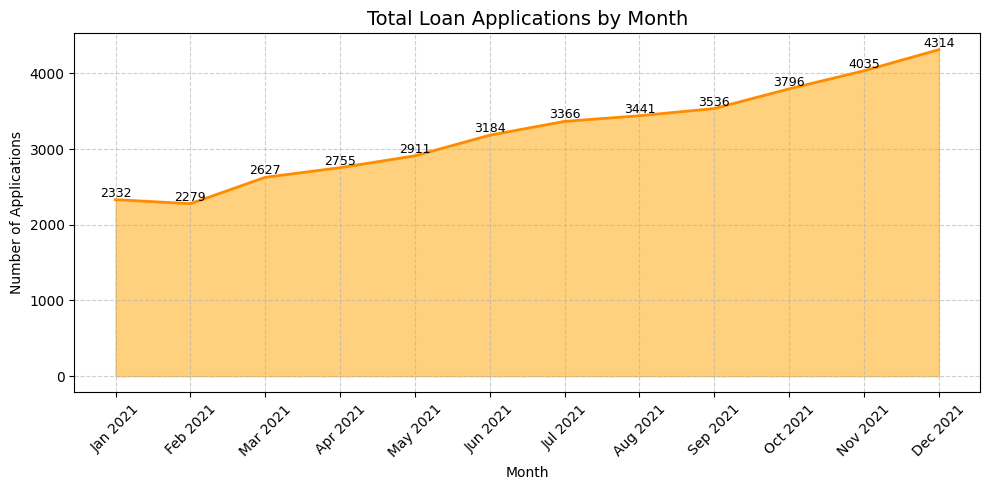

In [ ]:
import plotly.express as px

# Replace 'YourX', 'YourY', 'YourZ', 'YourCategory', and 'your_data' with actual column names and DataFrame
fig = px.scatter_3d(your_data, x='YourX', y='YourY', z='YourZ', color='YourCategory',
                    title='3D Scatter Plot', template='plotly_white')
fig.update_layout(scene = dict(xaxis_title='YourX', yaxis_title='YourY', zaxis_title='YourZ'))
fig.show()


### Regional Analysis By State for Toatal Funded Amount


In [ ]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Funded Amount by State (in Thousands)')
plt.xlabel('Funded Amount (\'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()



### Loan Term Analysis by Toatal Funded Amount


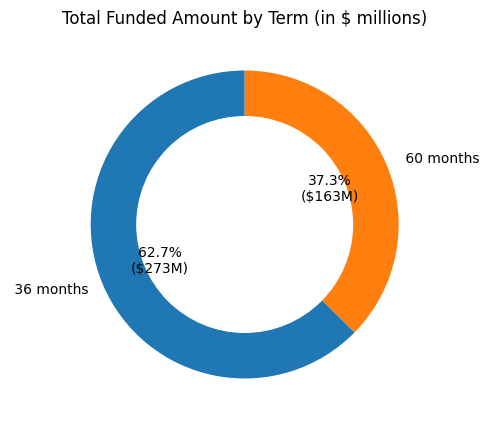

In [ ]:
import plotly.express as px

# Replace 'YourX', 'YourY', 'YourZ', 'YourCategory', and 'your_data' with actual column names and DataFrame
fig = px.scatter_3d(your_data, x='YourX', y='YourY', z='YourZ', color='YourCategory',
                    title='3D Scatter Plot', template='plotly_white')
fig.update_layout(scene = dict(xaxis_title='YourX', yaxis_title='YourY', zaxis_title='YourZ'))
fig.show()


### Employee Length by Total Funded Amount 

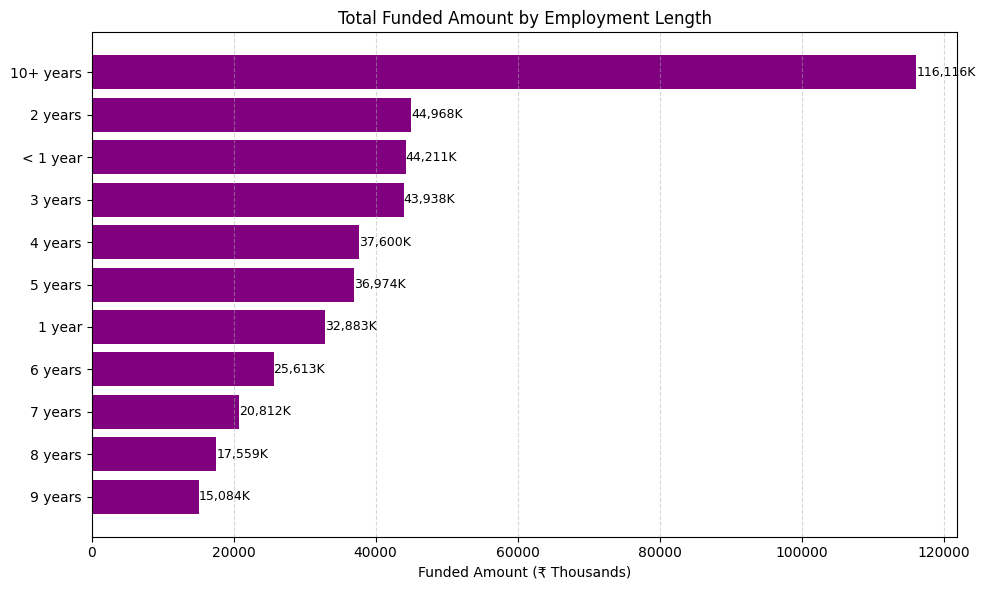

In [36]:

# Calculate emp_funding_thousands
emp_funding_thousands = df.groupby('emp_length')['loan_amount'].sum().sort_values() / 1000

plt.figure(figsize=(10, 6))

# Now, emp_funding_thousands is a Pandas Series, so it has an .index
bars = plt.barh(emp_funding_thousands.index, emp_funding_thousands, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f"{width:,.0f}K", va='center', fontsize=9) # Corrected f-string syntax

plt.xlabel("Funded Amount (₹ Thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Loan Purpose by Total Funded Amount

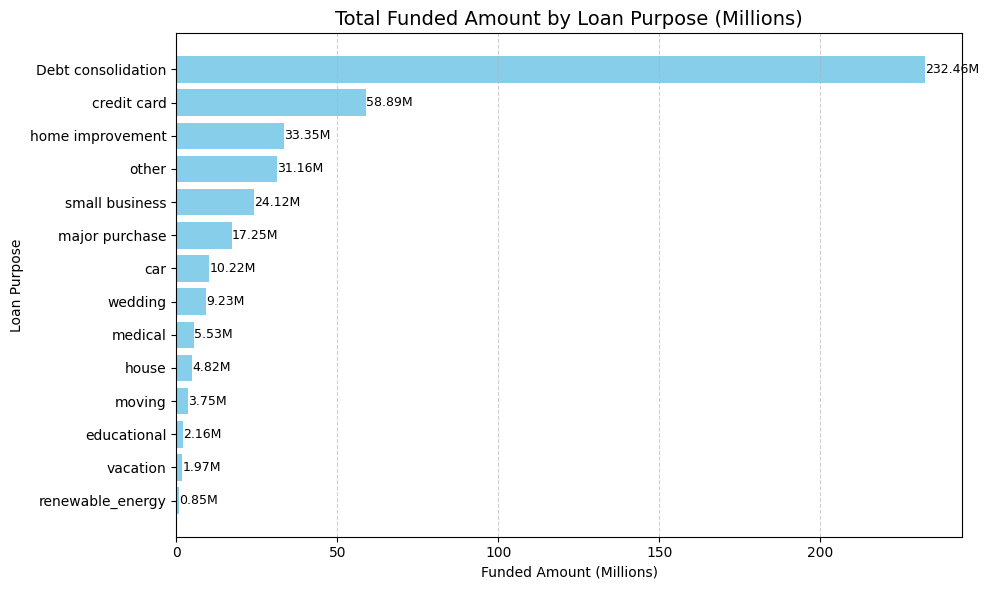

In [12]:
purpose_funding_millions = (df.groupby("purpose")["loan_amount"].sum().sort_values() / 1000000)
plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_funding_millions.index, purpose_funding_millions.values, color='skyblue')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}M', va='center', fontsize=9)
plt.title('Total Funded Amount by Loan Purpose (Millions)', fontsize=14)
plt.xlabel('Funded Amount (Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Home Ownership by Total Funded Amount

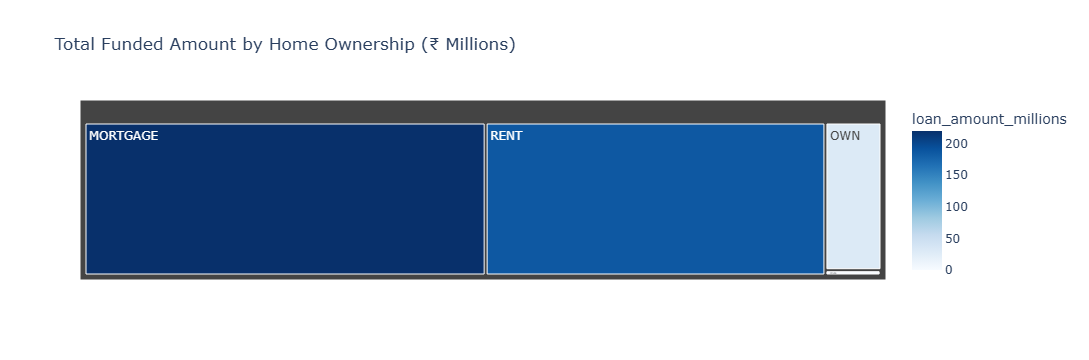

In [ ]:
import plotly.graph_objects as go

# Replace 'YourX', 'YourY', 'YourZ', and 'your_data' with actual column names and DataFrame
fig = go.Figure(data=[go.Bar3d(x=your_data['YourX'], y=your_data['YourY'], z=your_data['YourZ'], opacity=0.8)])
fig.update_layout(title='3D Bar Plot', scene = dict(xaxis_title='YourX', yaxis_title='YourY', zaxis_title='YourZ'))
fig.show()


---

### 🙏 Thank You

For questions or further discussion, please ping me for any Query.

*Prepared for: US_Bank*
*Date: September 20, 2025*